<a href="https://colab.research.google.com/github/martadominguezm/grupo-1-dscesp-0525/blob/master/entregable_2/0525_SupML_Grupo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entregable 2 - Microsoft Malware Prediction

## Importación de librerías

In [7]:
#!git clone -b yess https://github.com/martadominguezm/grupo-1-dscesp-0525.git

In [8]:
!git clone -b master https://github.com/martadominguezm/grupo-1-dscesp-0525.git

fatal: destination path 'grupo-1-dscesp-0525' already exists and is not an empty directory.


In [9]:
!pip install category_encoders

In [10]:
import zipfile

import numpy as np
import pandas as pd

# import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.max_rows', 500)
pd.options.display.float_format = '{:,.2f}'.format


from sklearn import preprocessing
from scipy.stats import chi2_contingency


## Importación de datos

In [11]:
 with zipfile.ZipFile("grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.zip", 'r') as z:
     z.extractall("grupo-1-dscesp-0525/entregable_2/data/raw/")

In [12]:
with zipfile.ZipFile("grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.zip", 'r') as z:
    z.extractall("grupo-1-dscesp-0525/entregable_2/data/raw/")

In [13]:
df = pd.read_csv('grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.csv', sep = ',')
df

/tmp/ipython-input-2536263748.py:1: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('grupo-1-dscesp-0525/entregable_2/data/raw/sample_mmp.csv', sep = ',')


,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.00,0,NaN,...,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.00,0,NaN,...,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.00,0,NaN,...,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.00,0,NaN,...,"48,473.00",1,NaN,0.00,0,0,0.00,0.00,15.00,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,win8defender,1.1.15200.1,4.18.1807.18075,1.275.511.0,0,7.00,0,NaN,...,"4,343.00",1,NaN,0.00,1,0,0.00,1.00,13.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,5826339,a739cacc292f3f1e745827c1ca6c6ada,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1090.0,0,7.00,0,NaN,...,"33,088.00",1,0.00,0.00,1,0,0.00,1.00,10.00,0
499996,5740034,a4c232d528d98343e8f1b73650da7b82,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1620.0,0,7.00,0,NaN,...,NaN,0,NaN,0.00,0,0,0.00,0.00,15.00,0
499997,8819786,fd16cd542d660848d272e4552bcccb1e,win8defender,1.1.15300.5,4.13.17134.112,1.275.1343.0,0,7.00,0,NaN,...,"41,727.00",0,NaN,0.00,0,0,0.00,0.00,8.00,0
499998,8713685,fa0841f8f6147de7c3d287e05270ed42,win8defender,1.1.15100.1,4.14.17639.18041,1.273.483.0,0,7.00,0,NaN,...,"11,947.00",0,NaN,0.00,0,0,0.00,0.00,1.00,0


In [14]:
#df = pd.read_csv('data/raw/sample_mmp.csv', sep = ',')
df

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.00,0,NaN,...,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.00,0,NaN,...,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.00,0,NaN,...,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.00,0,NaN,...,"48,473.00",1,NaN,0.00,0,0,0.00,0.00,15.00,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,win8defender,1.1.15200.1,4.18.1807.18075,1.275.511.0,0,7.00,0,NaN,...,"4,343.00",1,NaN,0.00,1,0,0.00,1.00,13.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,5826339,a739cacc292f3f1e745827c1ca6c6ada,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1090.0,0,7.00,0,NaN,...,"33,088.00",1,0.00,0.00,1,0,0.00,1.00,10.00,0
499996,5740034,a4c232d528d98343e8f1b73650da7b82,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1620.0,0,7.00,0,NaN,...,NaN,0,NaN,0.00,0,0,0.00,0.00,15.00,0
499997,8819786,fd16cd542d660848d272e4552bcccb1e,win8defender,1.1.15300.5,4.13.17134.112,1.275.1343.0,0,7.00,0,NaN,...,"41,727.00",0,NaN,0.00,0,0,0.00,0.00,8.00,0
499998,8713685,fa0841f8f6147de7c3d287e05270ed42,win8defender,1.1.15100.1,4.14.17639.18041,1.273.483.0,0,7.00,0,NaN,...,"11,947.00",0,NaN,0.00,0,0,0.00,0.00,1.00,0


## MLC2: Data Understanding

### MLC2.1: Análisis Univariante de datos

#### 1. Tamaño del dataset

In [15]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 84 entries, Unnamed: 0 to HasDetections
dtypes: float64(36), int64(18), object(30)
memory usage: 320.4+ MB


#### 2. Visualización directa de los datos

In [16]:
df.columns

Index(['Unnamed: 0', 'MachineIdentifier', 'ProductName', 'EngineVersion',
       'AppVersion', 'AvSigVersion', 'IsBeta', 'RtpStateBitfield',
       'IsSxsPassiveMode', 'DefaultBrowsersIdentifier',
       'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled',
       'HasTpm', 'CountryIdentifier', 'CityIdentifier',
       'OrganizationIdentifier', 'GeoNameIdentifier',
       'LocaleEnglishNameIdentifier', 'Platform', 'Processor', 'OsVer',
       'OsBuild', 'OsSuite', 'OsPlatformSubRelease', 'OsBuildLab',
       'SkuEdition', 'IsProtected', 'AutoSampleOptIn', 'PuaMode', 'SMode',
       'IeVerIdentifier', 'SmartScreen', 'Firewall', 'UacLuaenable',
       'Census_MDC2FormFactor', 'Census_DeviceFamily',
       'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier',
       'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier',
       'Census_ProcessorModelIdentifier', 'Census_ProcessorClass',
       'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeN

In [17]:
df.head(4).T

,0,1,2,3
Unnamed: 0,8427007,8829090,2731904,1359513
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5
ProductName,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075
AvSigVersion,1.273.1234.0,1.273.1282.0,1.273.781.0,1.275.1639.0
IsBeta,0,0,0,0
RtpStateBitfield,7.00,7.00,7.00,7.00
IsSxsPassiveMode,0,0,0,0
DefaultBrowsersIdentifier,NaN,NaN,NaN,NaN


In [18]:
print("Número de registros: {}".format(df.MachineIdentifier.count()))
print("Número de máquinas únicas: {}".format(df.MachineIdentifier.nunique()))

Número de registros: 500000
Número de máquinas únicas: 500000


Un aspecto importante en el trabajo con datos es comprender la integridad del índice DataFrame. En este caso, cada registro corresponde a una máquina determinada. A esta variable (**MachineIdentifier**) le llamaremos índice, y podemos explicitarlo en el Dataframe o no.

A continuación se incluye la descripción de las variables:

Unavailable or self-documenting column names are marked with an "NA".

- MachineIdentifier - Individual machine ID
- ProductName - Defender state information e.g. win8defender
- EngineVersion - Defender state information e.g. 1.1.12603.0
- AppVersion - Defender state information e.g. 4.9.10586.0
- AvSigVersion - Defender state information e.g. 1.217.1014.0
- IsBeta - Defender state information e.g. false
- RtpStateBitfield - NA
- IsSxsPassiveMode - NA
- DefaultBrowsersIdentifier - ID for the machine's default browser
- AVProductStatesIdentifier - ID for the specific configuration of a user's antivirus software
- AVProductsInstalled - NA
- AVProductsEnabled - NA
- HasTpm - True if machine has tpm
- CountryIdentifier - ID for the country the machine is located in
- CityIdentifier - ID for the city the machine is located in
- OrganizationIdentifier - ID for the organization the machine belongs in, organization ID is mapped to both specific companies and broad industries
- GeoNameIdentifier - ID for the geographic region a machine is located in
- LocaleEnglishNameIdentifier - English name of Locale ID of the current user
- Platform - Calculates platform name (of OS related properties and processor property)
- Processor - This is the process architecture of the installed operating system
- OsVer - Version of the current operating system
- OsBuild - Build of the current operating system
- OsSuite - Product suite mask for the current operating system.
- OsPlatformSubRelease - Returns the OS Platform sub-release (Windows Vista, Windows 7, Windows 8, TH1, TH2)
- OsBuildLab - Build lab that generated the current OS. Example: 9600.17630.amd64fre.winblue_r7.150109-2022
- SkuEdition - The goal of this feature is to use the Product Type defined in the MSDN to map to a 'SKU-Edition' name that is useful in population reporting. The valid Product Type are defined in %sdxroot%\data\windowseditions.xml. This API has been used since Vista and Server 2008, so there are many Product Types that do not apply to Windows 10. The 'SKU-Edition' is a string value that is in one of three classes of results. The design must hand each class.
- IsProtected - This is a calculated field derived from the Spynet Report's AV Products field. Returns: a. TRUE if there is at least one active and up-to-date antivirus product running on this machine. b. FALSE if there is no active AV product on this machine, or if the AV is active, but is not receiving the latest updates. c. null if there are no Anti Virus Products in the report. Returns: Whether a machine is protected.
- AutoSampleOptIn - This is the SubmitSamplesConsent value passed in from the service, available on CAMP 9+
- PuaMode - Pua Enabled mode from the service
- SMode - This field is set to true when the device is known to be in 'S Mode', as in, Windows 10 S mode, where only Microsoft - Store apps can be installed
- IeVerIdentifier - NA
- SmartScreen - This is the SmartScreen enabled string value from registry. This is obtained by checking in order, HKLM\SOFTWARE\Policies\Microsoft\Windows\System\SmartScreenEnabled and HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Explorer\SmartScreenEnabled. If the value exists but is blank, the value "ExistsNotSet" is sent in telemetry.
- Firewall - This attribute is true (1) for Windows 8.1 and above if windows firewall is enabled, as reported by the service.
- UacLuaenable - This attribute reports whether or not the "administrator in Admin Approval Mode" user type is disabled or enabled in UAC. The value reported is obtained by reading the regkey HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Policies\System\EnableLUA.
- ensus_MDC2FormFactor - A grouping based on a combination of Device Census level hardware characteristics. The logic used to define Form Factor is rooted in business and industry standards and aligns with how people think about their device. (Examples: Smartphone, Small Tablet, All in One, Convertible…)
- Census_DeviceFamily - AKA DeviceClass. Indicates the type of device that an edition of the OS is intended for. Example values: Windows.Desktop, Windows.Mobile, and iOS.Phone
- Census_OEMNameIdentifier - NA
- Census_OEMModelIdentifier - NA
- Census_ProcessorCoreCount - Number of logical cores in the processor
- Census_ProcessorManufacturerIdentifier - NA
- Census_ProcessorModelIdentifier - NA
- Census_ProcessorClass - A classification of processors into high/medium/low. Initially used for Pricing Level SKU. No longer maintained and updated
- Census_PrimaryDiskTotalCapacity - Amount of disk space on primary disk of the machine in MB
- Census_PrimaryDiskTypeName - Friendly name of Primary Disk Type - HDD or SSD
- Census_SystemVolumeTotalCapacity - The size of the partition that the System volume is installed on in MB
- Census_HasOpticalDiskDrive - True indicates that the machine has an optical disk drive (CD/DVD)
- Census_TotalPhysicalRAM - Retrieves the physical RAM in MB
- Census_ChassisTypeName - Retrieves a numeric representation of what type of chassis the machine has. A value of 0 means xx
- Census_InternalPrimaryDiagonalDisplaySizeInInches - Retrieves the physical diagonal length in inches of the primary display
- Census_InternalPrimaryDisplayResolutionHorizontal - Retrieves the number of pixels in the horizontal direction of the internal display.
- Census_InternalPrimaryDisplayResolutionVertical - Retrieves the number of pixels in the vertical direction of the internal display
- Census_PowerPlatformRoleName - Indicates the OEM preferred power management profile. This value helps identify the basic form factor of the device
- Census_InternalBatteryType - NA
- Census_InternalBatteryNumberOfCharges - NA
- Census_OSVersion - Numeric OS version Example - 10.0.10130.0
- Census_OSArchitecture - Architecture on which the OS is based. Derived from OSVersionFull. Example - amd64
- Census_OSBranch - Branch of the OS extracted from the OsVersionFull. Example - OsBranch = fbl_partner_eeap where OsVersion = 6.4.9813.0.amd64fre.fbl_partner_eeap.140810-0005
- Census_OSBuildNumber - OS Build number extracted from the OsVersionFull. Example - OsBuildNumber = 10512 or 10240
- Census_OSBuildRevision - OS Build revision extracted from the OsVersionFull. Example - OsBuildRevision = 1000 or 16458
- Census_OSEdition - Edition of the current OS. Sourced from HKLM\Software\Microsoft\Windows NT\CurrentVersion@EditionID in registry. Example: Enterprise
- Census_OSSkuName - OS edition friendly name (currently Windows only)
- Census_OSInstallTypeName - Friendly description of what install was used on the machine i.e. clean
- Census_OSInstallLanguageIdentifier - NA
- Census_OSUILocaleIdentifier - NA
- Census_OSWUAutoUpdateOptionsName - Friendly name of the WindowsUpdate auto-update settings on the machine.
- Census_IsPortableOperatingSystem - Indicates whether OS is booted up and running via Windows-To-Go on a USB stick.
- Census_GenuineStateName - Friendly name of OSGenuineStateID. 0 = Genuine
- Census_ActivationChannel - Retail license key or Volume license key for a machine.
- Census_IsFlightingInternal - NA
- Census_IsFlightsDisabled - Indicates if the machine is participating in flighting.
- Census_FlightRing - The ring that the device user would like to receive flights for. This might be different from the ring of the OS which is currently installed if the user changes the ring after getting a flight from a different ring.
- Census_ThresholdOptIn - NA
- Census_FirmwareManufacturerIdentifier - NA
- Census_FirmwareVersionIdentifier - NA
- Census_IsSecureBootEnabled - Indicates if Secure Boot mode is enabled.
- Census_IsWIMBootEnabled - NA
- Census_IsVirtualDevice - Identifies a Virtual Machine (machine learning model)
- Census_IsTouchEnabled - Is this a touch device ?
- Census_IsPenCapable - Is the device capable of pen input ?
- Census_IsAlwaysOnAlwaysConnectedCapable - Retreives information about whether the battery enables the device to be AlwaysOnAlwaysConnected .
- Wdft_IsGamer - Indicates whether the device is a gamer device or not based on its hardware combination.
- Wdft_RegionIdentifier - NA



Como se trata de un modelo de clasificación, tomaremos como target la variable **HasDetections**

#### 3. Tipo de atributos disponibles

In [19]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Unnamed: 0                                         500000 non-null  int64  
 1   MachineIdentifier                                  500000 non-null  object 
 2   ProductName                                        500000 non-null  object 
 3   EngineVersion                                      500000 non-null  object 
 4   AppVersion                                         500000 non-null  object 
 5   AvSigVersion                                       500000 non-null  object 
 6   IsBeta                                             500000 non-null  int64  
 7   RtpStateBitfield                                   498168 non-null  float64
 8   IsSxsPassiveMode                                   500000 non-null  int64 

#### 4. Estadísticos descriptivos

In [20]:
# numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"500,000.00","4,458,888.27","2,575,618.62",2.00,"2,227,692.50","4,461,367.50","6,690,936.00","8,921,471.00"
IsBeta,"500,000.00",0.00,0.00,0.00,0.00,0.00,0.00,1.00
RtpStateBitfield,"498,168.00",6.85,1.02,0.00,7.00,7.00,7.00,35.00
IsSxsPassiveMode,"500,000.00",0.02,0.13,0.00,0.00,0.00,0.00,1.00
DefaultBrowsersIdentifier,"24,061.00","1,652.82","1,004.75",1.00,788.00,"1,632.00","2,381.00","3,209.00"
AVProductStatesIdentifier,"498,062.00","47,850.91","14,023.09",3.00,"49,480.00","53,447.00","53,447.00","70,492.00"
AVProductsInstalled,"498,062.00",1.33,0.52,1.00,1.00,1.00,2.00,5.00
AVProductsEnabled,"498,062.00",1.02,0.17,0.00,1.00,1.00,1.00,4.00
HasTpm,"500,000.00",0.99,0.11,0.00,1.00,1.00,1.00,1.00
CountryIdentifier,"500,000.00",108.04,63.07,1.00,51.00,97.00,162.00,222.00


In [21]:
# categoricas
df.describe(include=['object']).T

,count,unique,top,freq
MachineIdentifier,500000,500000,41511160f407cf64af33b0ae2a3b55e1,1
ProductName,500000,3,win8defender,494604
EngineVersion,500000,53,1.1.15200.1,216491
AppVersion,500000,95,4.18.1807.18075,288809
AvSigVersion,500000,6455,1.273.1420.0,5771
Platform,500000,4,windows10,483048
Processor,500000,3,x64,454423
OsVer,500000,21,10.0.0.0,483830
OsPlatformSubRelease,500000,9,rs4,220779
OsBuildLab,499999,453,17134.1.amd64fre.rs4_release.180410-1804,206436


#### 5. Número de valores nulos

In [22]:
df[df.isnull().all(axis=1)]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


No hay ningún registro con todos sus valores nulos

In [23]:
df.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

,0
DefaultBrowsersIdentifier,475939
Census_IsFlightingInternal,415225
Census_ThresholdOptIn,318104
Census_IsWIMBootEnabled,317666
OrganizationIdentifier,154563
SMode,29848
CityIdentifier,18240
Wdft_IsGamer,16950
Wdft_RegionIdentifier,16950
Census_InternalBatteryNumberOfCharges,15038


In [24]:
possible_number_predictors_to_drop = ['DefaultBrowsersIdentifier','Census_IsFlightingInternal','Census_ThresholdOptIn', 'Census_IsWIMBootEnabled', 'OrganizationIdentifier']

for col in possible_number_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en DefaultBrowsersIdentifier: 95.19%
% de nulos en Census_IsFlightingInternal: 83.05%
% de nulos en Census_ThresholdOptIn: 63.62%
% de nulos en Census_IsWIMBootEnabled: 63.53%
% de nulos en OrganizationIdentifier: 30.91%


In [25]:
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

,0
PuaMode,499874
Census_ProcessorClass,497918
Census_InternalBatteryType,355603
SmartScreen,178596
Census_PrimaryDiskTypeName,709
Census_ChassisTypeName,37
Census_PowerPlatformRoleName,2
OsBuildLab,1
AppVersion,0
AvSigVersion,0


In [26]:
possible_obj_predictors_to_drop = ['PuaMode','Census_ProcessorClass','Census_InternalBatteryType', 'SmartScreen']

for col in possible_obj_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en PuaMode: 99.97%
% de nulos en Census_ProcessorClass: 99.58%
% de nulos en Census_InternalBatteryType: 71.12%
% de nulos en SmartScreen: 35.72%


r**Importante**: Como los predictors DefaultBrowsersIdentifier, PuaMode y Census_ProcessorClass tienen más de un 95% de nulos, más adelante los eliminaremos.

Más adelante chequeamos si hay que eliminar filas con nulos (que adectan a <0.5% del dataset).

#### 6. Distribución de los valores del target

In [27]:
df['HasDetections'].isna().sum()

np.int64(0)

In [28]:
#df['HasDetections'].value_counts(dropna=False)
df['HasDetections'].value_counts()

,count
HasDetections,
0,250047
1,249953


Por suerte, el dataset está balanceado :)

<Axes: xlabel='HasDetections', ylabel='count'>

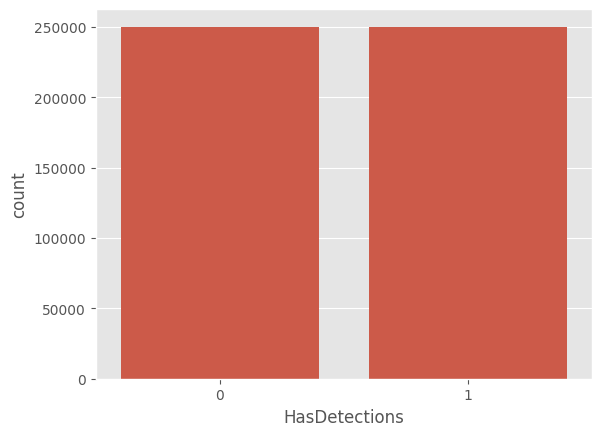

In [29]:
sns.countplot(data=df, x='HasDetections')

Vemos que el target contiene 2 valores en formato numérico:
- HasDetections = 1
- HasDetections = 0

In [30]:
df['HasDetections'].mean()

np.float64(0.499906)

In [31]:
TARGET = df['HasDetections']

# 7 Revisar columnas con pocos valores y mucha acumulación en un solo valor

Hacemos un data set de stats para ver cómo se distribuyen las observaciones en variables.

In [32]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])
display(stats_df)

,Feature,Unique_values,% missing values,% values in biggest category,type
6,IsBeta,2,0.00,100.00,int64
28,AutoSampleOptIn,2,0.00,100.00,int64
29,PuaMode,1,99.97,99.97,object
66,Census_IsPortableOperatingSystem,2,0.00,99.95,int64
36,Census_DeviceFamily,3,0.00,99.84,object
42,Census_ProcessorClass,3,99.58,99.58,object
34,UacLuaenable,5,0.12,99.26,float64
77,Census_IsVirtualDevice,2,0.18,99.11,float64
2,ProductName,3,0.00,98.92,object
13,HasTpm,2,0.00,98.78,int64


Revisamos aquellas que tienen pocos valores, y mucha acumulación en uno solo, separado por numéricas y categóricas

In [33]:
filtered_stats_df = stats_df[(stats_df['Unique_values'] <= 10) & (stats_df['% values in biggest category'] >= 80)]
display(filtered_stats_df.sort_values(by=['Unique_values']))

,Feature,Unique_values,% missing values,% values in biggest category,type
29,PuaMode,1,99.97,99.97,object
6,IsBeta,2,0.00,100.00,int64
28,AutoSampleOptIn,2,0.00,100.00,int64
66,Census_IsPortableOperatingSystem,2,0.00,99.95,int64
77,Census_IsVirtualDevice,2,0.18,99.11,float64
70,Census_IsFlightsDisabled,2,1.79,98.21,float64
8,IsSxsPassiveMode,2,0.00,98.28,int64
13,HasTpm,2,0.00,98.78,int64
33,Firewall,2,1.03,96.81,float64
78,Census_IsTouchEnabled,2,0.00,87.46,int64


Separamos las variables categóricas

In [34]:
filtered_stats_categoricas = filtered_stats_df[(filtered_stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
29,PuaMode,1,99.97,99.97,object
36,Census_DeviceFamily,3,0.00,99.84,object
42,Census_ProcessorClass,3,99.58,99.58,object
2,ProductName,3,0.00,98.92,object
19,Platform,4,0.00,96.61,object
71,Census_FlightRing,8,0.00,93.66,object
56,Census_OSArchitecture,3,0.00,90.89,object
20,Processor,3,0.00,90.88,object
67,Census_GenuineStateName,4,0.00,88.28,object


Revisamos cual es el rate en las categoricas on respecto al target. Validamos

---

si nos las podemos cargar porque no aportan señal

---



In [35]:
def rate_por_categorias_desde_df(df, filtered_stats_categoricas, features_col='Feature', target='HasDetections'):
    """
    Calcula rate (= media de target) y count por categoría para
    cada feature listado en filtered_stats_categoricas[features_col].

    Devuelve un único DataFrame con columnas:
    ['feature', 'category', 'rate', 'count'].
    """
    # 1) lista de nombres de columnas a procesar
    features = (filtered_stats_categoricas[features_col]
                .dropna()
                .astype(str)
                .unique()
                .tolist())

    # 2) iterar y acumular resultados
    out = []
    for feat in features:
        if feat not in df.columns:
            continue  # si algún nombre no existe en df, lo saltamos
        tmp = (df.groupby(feat)[target]
                 .agg(rate='mean', count='size')
                 .reset_index()
                 .sort_values('count', ascending=False))
        tmp.insert(0, 'feature', feat)          # añade la columna con el nombre de la variable
        tmp = tmp.rename(columns={feat: 'category'})
        out.append(tmp[['feature', 'category', 'rate', 'count']])

    # 3) concatenar todo
    if len(out) == 0:
        return pd.DataFrame(columns=['feature','category','rate','count'])
    return pd.concat(out, ignore_index=True)

In [36]:
tabla = rate_por_categorias_desde_df(
    df,
    filtered_stats_categoricas,
    features_col='Feature',
    target='HasDetections'
)

# ver resultados
display(tabla.head(100))

,feature,category,rate,count
0,PuaMode,on,0.75,126
1,Census_DeviceFamily,Windows.Desktop,0.50,499183
2,Census_DeviceFamily,Windows.Server,0.37,816
3,Census_DeviceFamily,Windows,0.00,1
4,Census_ProcessorClass,mid,0.57,1196
5,Census_ProcessorClass,low,0.53,546
6,Census_ProcessorClass,high,0.62,340
7,ProductName,win8defender,0.50,494604
8,ProductName,mse,0.48,5395
9,ProductName,mseprerelease,0.00,1


Al revisar el resultado, vemos que prácticamente todas dan bajo nivel de señal (hay el mismo volumen de infectadas que de no en prácticamente todas). Se podrían eliminar del análisis.

La única que salta esta regla es lso9 campos Processor y Census_OSArchitecture. Pero, se observa qu estos dos tienen los mismos valores, así que una de estas variables también la podemos eliminar del análisis

Conclusión:

Eliminar:

* PuaMode
* Census_DeviceFamily
* Census_ProcessorClass
* ProductName
* Platform
* Census_FlightRing
* Census_GenuineStateName





Decidir entreestas dos (tienen los mismos valores)
* Census_OSArchitecture
* Processor

Evaluamos numéricas con pocos valores y mucha acumulación, que en realidad son categoricas

In [37]:
filtered_stats_numericas = filtered_stats_df[(filtered_stats_df['type'] == 'int64') | (filtered_stats_df['type'] == 'float64')]
display(filtered_stats_numericas.sort_values(by=['Unique_values']))

,Feature,Unique_values,% missing values,% values in biggest category,type
6,IsBeta,2,0.00,100.00,int64
28,AutoSampleOptIn,2,0.00,100.00,int64
66,Census_IsPortableOperatingSystem,2,0.00,99.95,int64
77,Census_IsVirtualDevice,2,0.18,99.11,float64
8,IsSxsPassiveMode,2,0.00,98.28,int64
13,HasTpm,2,0.00,98.78,int64
70,Census_IsFlightsDisabled,2,1.79,98.21,float64
79,Census_IsPenCapable,2,0.00,96.23,int64
80,Census_IsAlwaysOnAlwaysConnectedCapable,2,0.81,93.51,float64
33,Firewall,2,1.03,96.81,float64


Paso las variables numéricas con pocos datos y mucha agregación como objects a otro dataset para evaluar su rate

In [38]:
numeric_features_to_convert = filtered_stats_numericas['Feature'].tolist()
numeric_features_as_object = df[numeric_features_to_convert].astype('object')
display(numeric_features_as_object.head())
display(numeric_features_as_object.info())
#añado el target para poder hacer el análisis de rate
numeric_features_as_object = pd.concat([numeric_features_as_object, df[['HasDetections']]], axis=1)

,IsBeta,AutoSampleOptIn,Census_IsPortableOperatingSystem,UacLuaenable,Census_IsVirtualDevice,HasTpm,IsSxsPassiveMode,Census_IsFlightsDisabled,AVProductsEnabled,RtpStateBitfield,Firewall,Census_IsPenCapable,IsProtected,SMode,Census_IsAlwaysOnAlwaysConnectedCapable,Census_HasOpticalDiskDrive,Census_ProcessorManufacturerIdentifier,Census_IsTouchEnabled,Census_IsFlightingInternal
0,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
1,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
2,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,1,1.00,0.00,0.00,0,5.00,1,NaN
3,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,5.00,0,NaN
4,0,0,0,1.00,0.00,1,0,0.00,1.00,7.00,1.00,0,1.00,0.00,0.00,0,1.00,1,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   IsBeta                                   500000 non-null  object
 1   AutoSampleOptIn                          500000 non-null  object
 2   Census_IsPortableOperatingSystem         500000 non-null  object
 3   UacLuaenable                             499377 non-null  object
 4   Census_IsVirtualDevice                   499099 non-null  object
 5   HasTpm                                   500000 non-null  object
 6   IsSxsPassiveMode                         500000 non-null  object
 7   Census_IsFlightsDisabled                 491067 non-null  object
 8   AVProductsEnabled                        498062 non-null  object
 9   RtpStateBitfield                         498168 non-null  object
 10  Firewall                                 494

None

In [39]:
tabla_numericas = rate_por_categorias_desde_df(
    numeric_features_as_object,
    filtered_stats_numericas,
    features_col='Feature',
    target='HasDetections'
)

# ver resultados
display(tabla_numericas.head(100))

,feature,category,rate,count
0,IsBeta,0.00,0.50,499999
1,IsBeta,1.00,0.00,1
2,AutoSampleOptIn,0.00,0.50,499986
3,AutoSampleOptIn,1.00,0.50,14
4,Census_IsPortableOperatingSystem,0.00,0.50,499739
5,Census_IsPortableOperatingSystem,1.00,0.52,261
6,UacLuaenable,1.00,0.50,496276
7,UacLuaenable,0.00,0.48,3086
8,UacLuaenable,48.00,0.77,13
9,UacLuaenable,2.00,1.00,1


Para descartar (planas o con grupos diminutos):

* IsBeta,
* AutoSampleOptIn,
* Census_IsPortableOperatingSystem,
* UacLuaenable (los valores “raros” tienen muy pocas filas),
* HasTpm,
* Firewall,
* Census_HasOpticalDiskDrive (diferencia pequeña),
* Census_ProcessorManufacturerIdentifier (planas o grupos ínfimos),
* Census_IsFlightsDisabled (grupos diminutos), etc.
* Smode (31% pero con 206 filas)



Necesitan más análisis (pasan el umbral o están muy cerca):

* IsProtected: valor 0 → 38% con 27.001 filas (~5.4%).
* Census_IsAlwaysOnAlwaysConnectedCapable: valor 1 → 37% con 28.391 filas (~5.7%).
* IsSxsPassiveMode: valor 1 → 37% con 8.621 filas (~1.7%).
* Census_IsVirtualDevice: valor 1 → 20% con 3.527 filas (~0.7%).
* AVProductsEnabled: valor 2 → 34% con 11.074 filas (~2.2%).
* RtpStateBitfield: valor 0 → 38% con 10.610 filas (~2.1%).
* Census_IsTouchEnabled: valor 1 → 45% con 62.717 filas (~12.5%) → justo en el umbral (-5 p.p.).



### Eliminamos las columnas identificadas arriba (categóricas y numéricas)

In [40]:
# quitar estas del borrado
#Census_IsFlightingInternal
#Census_ThresholdOptIn
#Census_IsWIMBootEnabled
#Census_InternalBatteryType

df_borrados = df.copy()
cols = ['DefaultBrowsersIdentifier','SMode','PuaMode','Census_ProcessorClass','Census_DeviceFamily','ProductName','Platform','Census_FlightRing','Census_GenuineStateName','Census_OSArchitecture','Processor','IsBeta','AutoSampleOptIn','Census_IsPortableOperatingSystem','UacLuaenable','HasTpm','Firewall','Census_HasOpticalDiskDrive','Census_ProcessorManufacturerIdentifier','Census_IsFlightsDisabled']

df_borrados.drop(columns=cols, inplace=True, errors='ignore')

In [41]:
stats_df_borrados = []
for col in df_borrados.columns:
    non_null_count = df_borrados[col].count()
    unique_values = df_borrados[col].nunique()
    if non_null_count > 0:
        percentage_most_frequent = df_borrados[col].value_counts(normalize=True, dropna=False).values[0] * 100
    else:
        percentage_most_frequent = 0

    stats_df_borrados.append((col, non_null_count, unique_values, percentage_most_frequent, df_borrados[col].dtype))

summary_df_borrados = pd.DataFrame(stats_df_borrados, columns=['Feature', 'Non-null Count', 'Unique Values', '% Most Frequent Value', 'Type'])
summary_df_borrados = summary_df_borrados.sort_values(by=['Unique Values'], ascending=False)
display(summary_df_borrados)

,Feature,Non-null Count,Unique Values,% Most Frequent Value,Type
0,Unnamed: 0,500000,500000,0.00,int64
1,MachineIdentifier,500000,500000,0.00,object
31,Census_SystemVolumeTotalCapacity,497024,142051,0.60,float64
26,Census_OEMModelIdentifier,494236,40697,3.42,float64
11,CityIdentifier,481760,37157,3.65,float64
54,Census_FirmwareVersionIdentifier,490939,23569,1.81,float64
4,AvSigVersion,500000,6455,1.15,object
7,AVProductStatesIdentifier,498062,5516,65.29,float64
39,Census_InternalBatteryNumberOfCharges,484962,5248,56.64,float64
28,Census_ProcessorModelIdentifier,497651,2243,3.24,float64


In [42]:
df_borrados

,Unnamed: 0,MachineIdentifier,EngineVersion,AppVersion,AvSigVersion,RtpStateBitfield,IsSxsPassiveMode,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,1.1.15100.1,4.18.1807.18075,1.273.1234.0,7.00,0,"53,447.00",1.00,1.00,...,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,1.1.15100.1,4.18.1807.18075,1.273.1282.0,7.00,0,"53,447.00",1.00,1.00,...,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,1.1.15100.1,4.9.10586.1106,1.273.781.0,7.00,0,"46,781.00",2.00,1.00,...,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,1.1.15200.1,4.18.1807.18075,1.275.1639.0,7.00,0,"53,447.00",1.00,1.00,...,"48,473.00",1,NaN,0.00,0,0,0.00,0.00,15.00,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,1.1.15200.1,4.18.1807.18075,1.275.511.0,7.00,0,"47,238.00",2.00,1.00,...,"4,343.00",1,NaN,0.00,1,0,0.00,1.00,13.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,5826339,a739cacc292f3f1e745827c1ca6c6ada,1.1.15200.1,4.18.1807.18075,1.275.1090.0,7.00,0,"53,447.00",1.00,1.00,...,"33,088.00",1,0.00,0.00,1,0,0.00,1.00,10.00,0
499996,5740034,a4c232d528d98343e8f1b73650da7b82,1.1.15100.1,4.18.1807.18075,1.273.1620.0,7.00,0,"53,447.00",1.00,1.00,...,NaN,0,NaN,0.00,0,0,0.00,0.00,15.00,0
499997,8819786,fd16cd542d660848d272e4552bcccb1e,1.1.15300.5,4.13.17134.112,1.275.1343.0,7.00,0,"53,447.00",1.00,1.00,...,"41,727.00",0,NaN,0.00,0,0,0.00,0.00,8.00,0
499998,8713685,fa0841f8f6147de7c3d287e05270ed42,1.1.15100.1,4.14.17639.18041,1.273.483.0,7.00,0,"43,856.00",2.00,1.00,...,"11,947.00",0,NaN,0.00,0,0,0.00,0.00,1.00,0


In [47]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0  # Handle the case where one variable has only one unique value
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix




In [48]:
def matriz_correlacion(dfg,listdf):
  # calculate Cramér's V matrix
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

## Análisis de variables de GEO

In [43]:
geo_columns = [
    'CountryIdentifier',
    'CityIdentifier',
    'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier',
    'Wdft_RegionIdentifier',
    'OrganizationIdentifier',
    'HasDetections'
]

df_geo = df_borrados[geo_columns].copy()

In [44]:
df_geo.isna().sum()


,0
CountryIdentifier,0
CityIdentifier,18240
GeoNameIdentifier,16
LocaleEnglishNameIdentifier,0
Wdft_RegionIdentifier,16950
OrganizationIdentifier,154563
HasDetections,0


Convierto todos los campos de df_geo en categóricos para crear el valor "missing values" y poder hacer un encoding decente

In [45]:
feature_columns = [
    'CountryIdentifier', 'CityIdentifier', 'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier', 'Wdft_RegionIdentifier', 'OrganizationIdentifier'
]
# Para cada una de las columnas, convertir a string y reemplazar nan por "Missing_ID"

for col in feature_columns:

    df_geo[col] = df_geo[col].astype(str)
    df_geo[col].replace('nan', 'Missing_ID', inplace=True)

/tmp/ipython-input-1452317793.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_geo[col].replace('nan', 'Missing_ID', inplace=True)
/tmp/ipython-input-1452317793.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

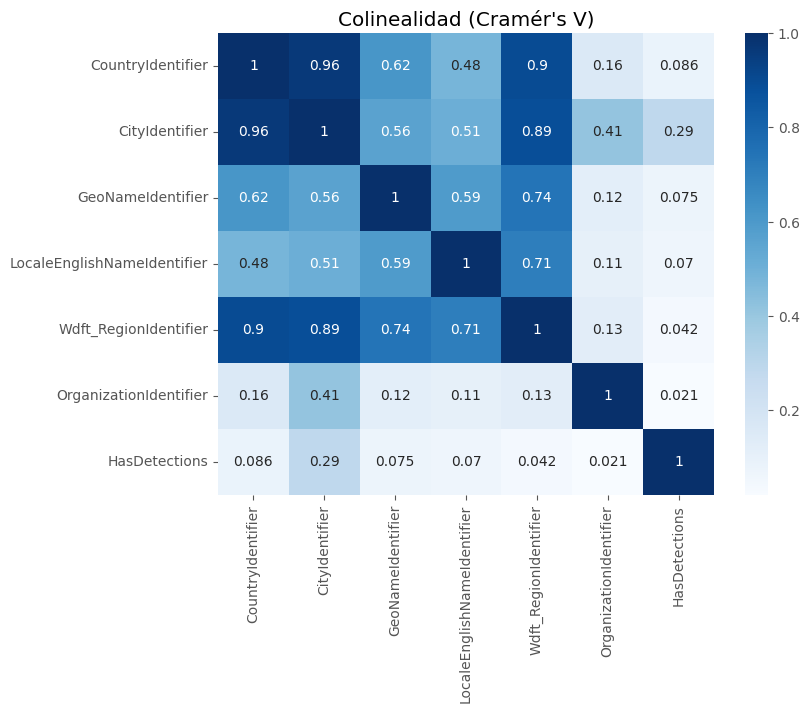

In [49]:
matriz_correlacion(df_geo, geo_columns)

Según la matriz, hay una alta correlación de:

City Identifier con Coutry Identifier, Wdft_RegionIdentifier
Wdft_Region identifier con GeoNameIdentifier
Wdft_RegionIdentifier con LocaleEnglishNameIdentifier

A priori, parece que la variable Wdtf_RegionIdentifier se puede borrar porque está reflejada en otras tres variables



Creo una nueva columna en df_geo con el cálculo de frecuencia de cada combinación de las columnas del dataset, y lo guardo en 'Location_Frequency'. Este valor me da el número de veces que una combinacion de los valores se repite a lo largo del dataset.

La Necesidad de la Frecuencia (El "Factor Confianza")

Las variables Target Encoded (como CityIdentifier) convierten una ciudad en una puntuación de riesgo (un número entre 0 y 1). El modelo OLS trata inicialmente todos los números por igual.

La Location_Frequency_Log se calcula para corregir esta debilidad inherente al Target Encoding.

El Riesgo de la Muestra Pequeña (Ruido) Imagina dos ciudades con la misma puntuación de riesgo:
Ciudad	Casos en el Dataset	Puntuación de Riesgo (CityIdentifier)
Ciudad A	10	0.80
Ciudad B	10,000	0.80
Sin Frecuencia: El modelo OLS ve 0.80 y 0.80. Los trata como el mismo riesgo.

Realidad: La puntuación de 0.80 de la Ciudad A es inestable (se basa en muy pocos datos y podría ser un error). La puntuación de 0.80 de la Ciudad B es muy fiable (estable).

Lo que Aporta Location_Frequency_Log Al incluir la frecuencia (transformada logarítmicamente) en el modelo, le das una herramienta para:
Ponderar la Confianza: El modelo aprende a darle más peso predictivo a la puntuación de riesgo (CityIdentifier) de la Ciudad B (alta frecuencia) y a darle menos peso a la misma puntuación de riesgo de la Ciudad A (baja frecuencia).

Reducir el Overfitting: Evitas que el modelo aprenda a predecir basándose en el ruido de las categorías raras.

In [52]:
# 1. Define the six identifier columns (must be in their string/categorical form)
unique_geo_cols = [
    'CountryIdentifier',
    'CityIdentifier',
    'GeoNameIdentifier',
    'LocaleEnglishNameIdentifier',
    'Wdft_RegionIdentifier',
    'OrganizationIdentifier'
]

# 2. Calculate the frequency of each unique combination and store it as a new column
# .groupby(unique_geo_cols) groups by the unique profile.
# .transform('count') applies the count to the target and maps the result back to every row.
df_geo['Location_Frequency'] = df_geo.groupby(unique_geo_cols)['HasDetections'].transform('count')

# 3. Print the head to verify the new column and its calculation
print("New 'Location_Frequency' feature successfully created in df_geo.")
print("\nVerification (First 5 Rows):")
print(df_geo[['Location_Frequency'] + unique_geo_cols].head())

New 'Location_Frequency' feature successfully created in df_geo.

Verification (First 5 Rows):
   Location_Frequency CountryIdentifier CityIdentifier GeoNameIdentifier  \
0                 323                 8        85219.0             205.0   
1                   1               129        54198.0             126.0   
2                 147               149       122689.0             181.0   
3                  10               164       114587.0             205.0   
4                   1               207        72421.0             277.0   

  LocaleEnglishNameIdentifier Wdft_RegionIdentifier OrganizationIdentifier  
0                         172                  11.0             Missing_ID  
1                         124                   3.0             Missing_ID  
2                          56                  15.0                   27.0  
3                         172                  15.0                   27.0  
4                          75                  13.0            

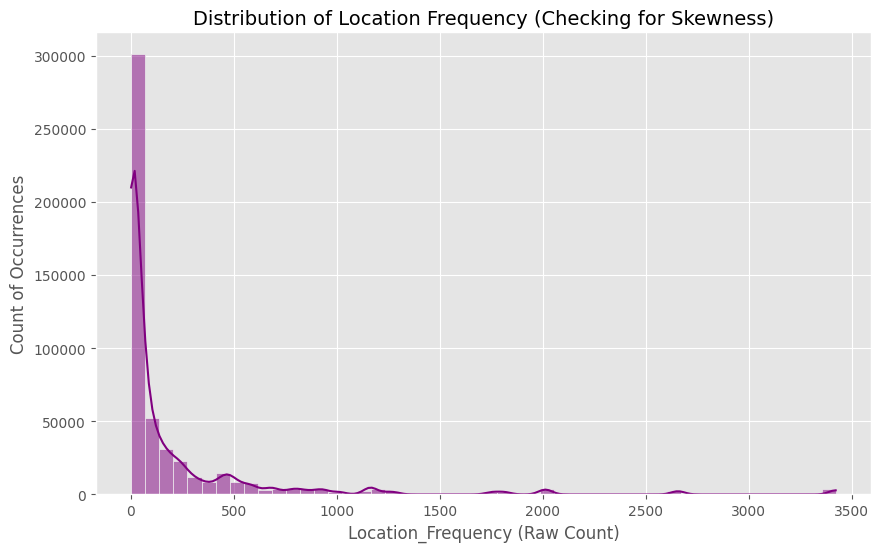

In [53]:
#h istograma de Location frequency

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_geo,
    x='Location_Frequency',
    kde=True,
    bins=50,  # Use a sufficient number of bins for detail
    color='purple'
)

plt.title('Distribution of Location Frequency (Checking for Skewness)', fontsize=14)
plt.xlabel('Location_Frequency (Raw Count)', fontsize=12)
plt.ylabel('Count of Occurrences', fontsize=12)

plt.show()

Location_Frequency tiene muchos valores hacia la izquierda y sus valores son altos. Convierto Location_Frequency en logaritmica para mitigar y normalizar los datos. Elimino la columna original

In [54]:
df_geo['Location_Frequency_Log'] = np.log1p(df_geo['Location_Frequency'])

# Now, drop the original raw frequency column to avoid collinearity
df_geo.drop('Location_Frequency', axis=1, inplace=True)


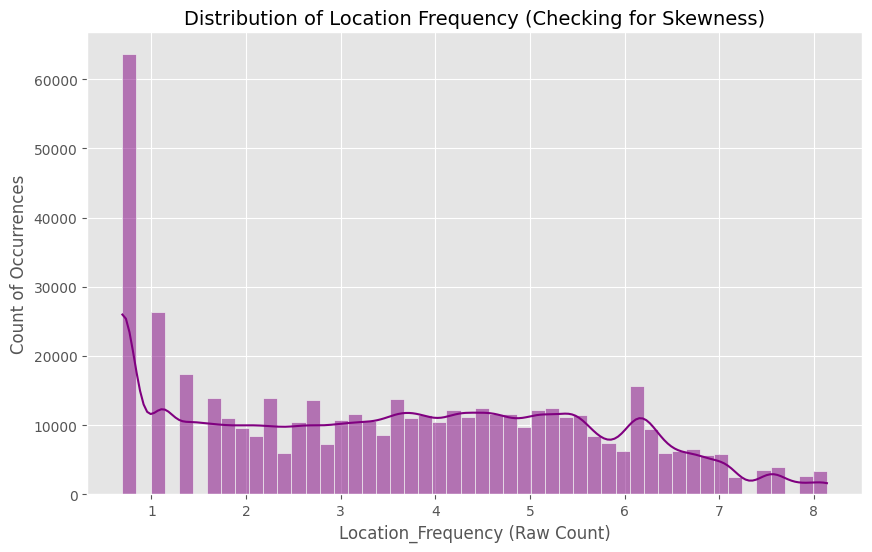

In [55]:
plt.figure(figsize=(10, 6))

# Generate the Histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(
    data=df_geo,
    x='Location_Frequency_Log',
    kde=True,
    bins=50,  # Use a sufficient number of bins for detail
    color='purple'
)

plt.title('Distribution of Location Frequency (Checking for Skewness)', fontsize=14)
plt.xlabel('Location_Frequency (Raw Count)', fontsize=12)
plt.ylabel('Count of Occurrences', fontsize=12)

plt.show()

### Análisis variables: SISTEMA OPERATIVO

In [ ]:
cols = ["MachineIdentifier",
        "OsVer","OsBuild","OsSuite",
        "SkuEdition",
        "Census_OSVersion","Census_OSBranch","Census_OSBuildNumber","Census_OSBuildRevision","Census_OSEdition",
        "Census_OSSkuName","Census_OSInstallTypeName","Census_OSInstallLanguageIdentifier","Census_OSWUAutoUpdateOptionsName",
        "Census_ActivationChannel","Census_IsFlightingInternal","Census_IsWIMBootEnabled","Census_ThresholdOptIn",
        "HasDetections"]


df_borrados = df_borrados[cols]
df_borrados

#### Correlación

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return 0  # no se puede calcular bien
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom == 0:
        return 0
    return np.sqrt(phi2corr / denom)


In [ ]:
categorical_cols = df_borrados.select_dtypes(include=['object', 'category']).columns

# Creamos un DataFrame vacío para la matriz
cramers_results = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# Calcular Cramér's V para cada par
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(df_borrados[col1], df_borrados[col2])


plt.figure(figsize=(12,10))
sns.heatmap(cramers_results, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Cramér’s V entre variables categóricas")
plt.show()


In [ ]:
# Select only numeric columns
num_cols = df_borrados.select_dtypes(include=[np.number]).columns
corr_matrix = df_borrados[num_cols].corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,         # muestra los números en las celdas
    fmt=".2f",
    cmap="coolwarm",    # puedes cambiar a "vlag", "RdBu_r", etc.
    cbar=True
)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

#### Census_OSEdition, Census_OSSkuName y SkuEdition

Como se puede ver en el gráfico de correlaciones de arriba, las 3 variables están altamente correlacionadas.

'Census_OSEdition' == 'Census_OSSkuName'. Son identificas, salvo casos escritos diferente como:
499973	ProfessionalEducation	PROFESSIONAL
499974	ProfessionalN	PROFESSIONAL_N
499980	CoreSingleLanguage	CORE_SINGLELANGUAGE


Ojo! porque pensaba hacer categorías para OSEdition pero son muy similares a las del campo SkuEdition.
    # Core / Home
    'Core': 'Core/Home',
    'CoreSingleLanguage': 'Core/Home',
    'CoreCountrySpecific': 'Core/Home',
    'CoreN': 'Core/Home',

    # Professional
    'Professional': 'Professional',
    'ProfessionalN': 'Professional',
    'ProfessionalEducation': 'Professional',
    'ProfessionalEducationN': 'Professional',
    'ProfessionalWorkstation': 'Professional',
    'ProfessionalWorkstationN': 'Professional',

    # Enterprise
    'Enterprise': 'Enterprise',
    'EnterpriseN': 'Enterprise',
    'EnterpriseS': 'Enterprise',
    'EnterpriseSN': 'Enterprise',

    # Education
    'Education': 'Education',
    'EducationN': 'Education',

    # Server
    'ServerDatacenterEval': 'Server',
    'ServerStandard': 'Server',
    'ServerStandardEval': 'Server',
    'ServerSolution': 'Server',

    # Cloud
    'Cloud': 'Cloud',
    'CloudN': 'Cloud'


Solución: Borrar 'Census_OSEdition' y 'Census_OSSkuName'. Y quedarnos únicamente con OSEdition para posteriormente transformarla en numérica.

In [ ]:
df_borrados[df_borrados["Census_OSEdition"].str.upper() != df_borrados["Census_OSSkuName"]][['Census_OSEdition','Census_OSSkuName']]

In [ ]:
df_borrados.groupby('Census_OSEdition').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

In [ ]:
pd.crosstab(df_borrados['Census_OSEdition'], df_borrados['SkuEdition'])

In [ ]:
df_borrados.SkuEdition.value_counts()

#### Census_OSBuildNumber, OsBuild, Census_OSBuildRevision y Census_OSVersion

De primeras vamos a eliminar Census_OSBuildNumber y Census_OSBuildRevision porque Census_OSVersion es la versión completa del OS y se compone de ambos campos

'Census_OSBuildNumber' == 'OsBuild'. Son casi identicas, no sé por que hay 25k filas que no coinciden los valores, pero yo creo que es un error.

Solución: borrar OsBuild

Esto aún dudoso ((((Por otro lado, ambas tienen una fuerte correlación inversa con Census_OSBuildRevision y por tanto eliminaremos una.
Solución: nos quedamos con Census_OSBuildRevision por tener más variabilidad y medias del target por valor más amplias y significativas))))

In [ ]:
df_borrados[['OsBuild','Census_OSBuildNumber','Census_OSBuildRevision','Census_OSVersion']].head()

In [ ]:
df_borrados[df_borrados["OsBuild"] != df_borrados["Census_OSBuildNumber"]][['OsBuild','Census_OSBuildNumber']]

In [ ]:
df_borrados.Census_OSVersion.value_counts()

In [ ]:
df_borrados['Census_OSVersion'] = (
    df_borrados['Census_OSVersion']
    .fillna('Unknown')
    .astype(str)
)

value_counts = df_borrados['Census_OSVersion'].value_counts(normalize=True)
minor_categories = value_counts[value_counts < 0.008].index

df_borrados['Census_OSVersion_grouped'] = (
    df_borrados['Census_OSVersion']
    .replace(minor_categories, 'Other')
)

In [ ]:
df_borrados.Census_OSVersion_grouped.value_counts(normalize=True)

#### Census_OSBranch

**Census_OSBranch**

Census_OSBranch representa ramas de desarrollo de Windows, y hay un orden implícito:
ramas bajas -> versiones antiguas; ramas altas -> versiones más recientes o de prueba.


th1, th2 → Windows 10 iniciales (Threshold), versiones 1507 y 1511.

rs1, rs2, rs3, rs4, rs5 → Windows 10 más recientes (Redstone 1 a 5), versiones 1607 a 1809.

rs*_svc_escrow → ramas internas de servicio, builds cercanas a la oficial pero usadas para testing o soporte.

rs*_sigma → build interna muy concreta, rara en producción.

rs_prerelease → Insider Preview, versiones de prueba.

winblue_ltsb_escrow → Windows 8.1 LTSB, antiguo.

In [ ]:
df_borrados.Census_OSBranch.value_counts()

In [ ]:
branch_mapping = {
    'th1': 1,
    'th1_st1': 2,
    'th2_release': 3,
    'th2_release_sec': 4,
    'rs1_release': 5,
    'rs2_release': 6,
    'rs3_release': 7,
    'rs3_release_svc_escrow': 8,
    'rs3_release_svc_escrow_im': 9,
    'rs4_release': 10,
    'rs5_release': 11,
    'rs5_release_sigma': 12,
    'rs_prerelease': 0,
    'rs_prerelease_flt': 0,
    'winblue_ltsb_escrow': 0
}

df_borrados['Census_OSBranch_transformed'] = df_borrados['Census_OSBranch'].map(branch_mapping).fillna(13).astype(int)

In [ ]:
df_borrados.Census_OSBranch_transformed.value_counts()

#### OsVer

Esta variable directamente nos la vamos a cargar porque el 97% de los registros del dataset tienen la misma versión (10.0.0.0).

El resto a priori no nos aporta nada porque las otras dos versiones que contienen más registros 6.1.1.0	y 6.3.0.0 tienen una media con respecto al target de aprox del 50% (no nos indica nada). Más adelante, en una próxima iteración estudiar si unificar este campo en dos valores OSVer: 10 vs. 6

In [ ]:
df_borrados.value_counts('OsVer', normalize=True)

In [ ]:
df_borrados.groupby('OsVer').agg(
        count=('HasDetections', 'size'),           # cuenta de filas por OsVer
        mean_HasDetections=('HasDetections', 'mean')  # media del target por OsVer
    ).sort_index()

In [ ]:
stats = []
for col in ['OsVer']:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])
display(stats_df)

#### Census_IsFlightingInternal, Census_IsWIMBootEnabled,	Census_ThresholdOptIn

##### Census_IsFlightingInternal

A priori, como Census_IsFlightingInternal tiene el 83% de registros nulos, la vamos a eliminar.

En una segunda iteración veremos si incluirla.

In [ ]:
df_borrados.Census_IsFlightingInternal.value_counts(dropna=False)

In [ ]:
df_borrados.Census_IsFlightingInternal.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.groupby('Census_IsFlightingInternal').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

##### Census_IsWIMBootEnabled

Lo mismo para Census_IsWIMBootEnabled, la eliminamos de momento.

In [ ]:
df_borrados.Census_IsWIMBootEnabled.value_counts(dropna=False)

In [ ]:
df_borrados.Census_IsWIMBootEnabled.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.groupby('Census_IsWIMBootEnabled').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

##### Census_ThresholdOptIn

Y lo mismo para esta.

In [ ]:
df_borrados.Census_ThresholdOptIn.value_counts(dropna=False)

In [ ]:
df_borrados.Census_ThresholdOptIn.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.groupby('Census_ThresholdOptIn').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

#### Census_OSInstallLanguageIdentifier

Parece una variable numérica pero no lo es. Representa el idioma configurado en la instalación de la máquina y por tanto no la podemos dejar como numero y normalizar porque no tendría sentido.

La vamos a transformar en categórica y agrupar los idiomas menos frecuentes.

In [ ]:
df_borrados.Census_OSInstallLanguageIdentifier.isna().sum()

In [ ]:
df_borrados.Census_OSInstallLanguageIdentifier.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados['Census_OSInstallLanguageIdentifier'] = (
    df_borrados['Census_OSInstallLanguageIdentifier']
    .fillna('Unknown')
    .astype(str)
)

value_counts = df_borrados['Census_OSInstallLanguageIdentifier'].value_counts(normalize=True)
minor_categories = value_counts[value_counts < 0.01].index

df_borrados['Census_OSInstallLanguageIdentifier_grouped'] = (
    df_borrados['Census_OSInstallLanguageIdentifier']
    .replace(minor_categories, 'Other')
)

In [ ]:
df_borrados.Census_OSInstallLanguageIdentifier_grouped.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.loc[df_borrados['Census_OSInstallLanguageIdentifier_grouped'] != 'Other', 'Census_OSInstallLanguageIdentifier_grouped'] = (
    df_borrados.loc[df_borrados['Census_OSInstallLanguageIdentifier_grouped'] != 'Other', 'Census_OSInstallLanguageIdentifier_grouped'].astype(str).str.split('.').str[0])

In [ ]:
df_borrados.groupby('Census_OSInstallLanguageIdentifier_grouped').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

#### Census_ActivationChannel

Esta variable describe cómo se activó la licencia del sistema operativo.

La dejamos tal cual y luego la transformamos en numérica

In [ ]:
df_borrados.Census_ActivationChannel.dtype

In [ ]:
df_borrados.Census_ActivationChannel.value_counts(dropna=False)

In [ ]:
df_borrados.groupby('Census_ActivationChannel').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

Ojo con el valor Retail:TB:Eval, no lo vamos a agrupar con Volume:MAK ni OEM:NONSLP	 en "Other" porque puede ser interesante a la hora de descartar infecciones...

#### Census_OSWUAutoUpdateOptionsName

Esta variable describe la configuración de actualización automática del sistema operativo.

In [ ]:
df_borrados.Census_OSWUAutoUpdateOptionsName.value_counts(dropna=False)

In [ ]:
df_borrados.Census_OSWUAutoUpdateOptionsName.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.groupby('Census_OSWUAutoUpdateOptionsName').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

In [ ]:
df_borrados['Census_OSWUAutoUpdateOptionsName'] = (
    df_borrados['Census_OSWUAutoUpdateOptionsName']
    .fillna('UNKNOWN')
    .astype(str)
)

value_counts = df_borrados['Census_OSWUAutoUpdateOptionsName'].value_counts(normalize=True)
minor_categories = value_counts[value_counts < 0.10].index

df_borrados['Census_OSWUAutoUpdateOptionsName_grouped'] = (
    df_borrados['Census_OSWUAutoUpdateOptionsName']
    .replace(minor_categories, 'Other')
)

In [ ]:
df_borrados.Census_OSWUAutoUpdateOptionsName_grouped.value_counts(dropna=False)

#### Census_OSInstallTypeName

In [ ]:
df_borrados.Census_OSInstallTypeName.value_counts(dropna=False)

In [ ]:
df_borrados.Census_OSInstallTypeName.value_counts(dropna=False, normalize=True)

In [ ]:
df_borrados.groupby('Census_OSInstallTypeName').agg(
        count=('HasDetections', 'size'),
        mean_HasDetections=('HasDetections', 'mean')
    ).sort_index()

In [ ]:
df_borrados['Census_OSInstallTypeName'] = (
    df_borrados['Census_OSInstallTypeName']
    .fillna('UNKNOWN')
    .astype(str)
)

value_counts = df_borrados['Census_OSInstallTypeName'].value_counts(normalize=True)
minor_categories = value_counts[value_counts < 0.07].index

df_borrados['Census_OSInstallTypeName_grouped'] = (
    df_borrados['Census_OSInstallTypeName']
    .replace(minor_categories, 'Other')
)

In [ ]:
df_borrados.Census_OSInstallTypeName_grouped.value_counts(dropna=False)

In [ ]:
#### BORRAMOS COLUMNAS #####

In [ ]:
cols_to_drop_after_cleaning = ["Census_OSSkuName","Census_OSEdition",
                                'OsBuild','Census_OSBuildNumber','Census_OSBuildRevision',
                                "Census_OSVersion",
                                  "Census_OSBranch",
                                  "OsVer",
                                   "Census_IsFlightingInternal","Census_IsWIMBootEnabled","Census_ThresholdOptIn",
                                  "Census_OSInstallLanguageIdentifier",
                                  "Census_OSWUAutoUpdateOptionsName",
                                  "Census_OSInstallTypeName"]

df_borrados.drop(cols_to_drop_after_cleaning, axis=1, inplace=True)

In [ ]:
#### Volvemos a analizar correlaciones

In [ ]:
df_borrados.head()

In [ ]:
df_borrados.dtypes

In [ ]:
categorical_cols = df_borrados.select_dtypes(include=['object', 'category']).columns

# Creamos un DataFrame vacío para la matriz
cramers_results = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# Calcular Cramér's V para cada par
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(df_borrados[col1], df_borrados[col2])


plt.figure(figsize=(12,10))
sns.heatmap(cramers_results, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Cramér’s V entre variables categóricas")
plt.show()

In [ ]:
# Select only numeric columns
num_cols = df_borrados.select_dtypes(include=[np.number]).columns
corr_matrix = df_borrados[num_cols].corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,         # muestra los números en las celdas
    fmt=".2f",
    cmap="coolwarm",    # puedes cambiar a "vlag", "RdBu_r", etc.
    cbar=True
)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

In [ ]:
df_borrados.head()

In [ ]:
frequency_encoding_cols = ['Census_OSVersion_grouped']
ohe_cols = ['SkuEdition','Census_ActivationChannel','Census_OSInstallLanguageIdentifier_grouped','Census_OSWUAutoUpdateOptionsName_grouped','Census_OSInstallTypeName_grouped']
normalize_cols = ['OsSuite','Census_OSBranch_transformed']

In [ ]:
target = "HasDetections"
dfs = {}

for var in df[['OsBuild','Census_OSBuildNumber', 'Census_OSBuildRevision']]:
    if var != 'MachineIdentifier':
        # Conteos incluyendo NaN
        counts = df[var].value_counts(dropna=False)
        counts_norm = df[var].value_counts(normalize=True, dropna=False)

        # Media del target para valores no nulos
        target_mean = df.groupby(var)[target].mean()

        # Si hay NaN, agregarlos con su media
        if df[var].isna().any():
            target_mean.loc[pd.NA] = df[df[var].isna()][target].mean()

        # Crear el DataFrame resumen
        summary = pd.DataFrame({
            'count': counts,
            'count_normalized': counts_norm,
            'target_mean': target_mean
        })

        # Ordenar de mayor a menor según target_mean
        summary = summary.sort_values(by='target_mean', ascending=False)

        dfs[var] = summary

        print(f"\n--- Summary for {var} ---")
        print(summary)


In [ ]:
stats_df_borrados = []
for col in df_borrados.columns:
    non_null_count = df_borrados[col].count()
    unique_values = df_borrados[col].nunique()
    if non_null_count > 0:
        percentage_most_frequent = df_borrados[col].value_counts(normalize=True, dropna=False).values[0] * 100
    else:
        percentage_most_frequent = 0

    stats_df_borrados.append((col, non_null_count, unique_values, percentage_most_frequent, df_borrados[col].dtype))

summary_df_borrados = pd.DataFrame(stats_df_borrados, columns=['Feature', 'Non-null Count', 'Unique Values', '% Most Frequent Value', 'Type'])
summary_df_borrados = summary_df_borrados.sort_values(by=['Unique Values'], ascending=False)
display(summary_df_borrados)

In [ ]:
df_borrados.head(3).T

#### Duplicados

#### Nulos

#### Outliers

In [ ]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0  # Handle the case where one variable has only one unique value
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix




In [ ]:
calculate_numeric_correlation_matrix(df_borrados, ['Census_PrimaryDiskTotalCapacity', 'Census_TotalPhysicalRAM'])

In [ ]:
def matriz_correlacion(dfg,listdf):
  # calculate Cramér's V matrix
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

#### Normalización

#### Transformaciones

# 8. Evaluar multicolinealidad

In [ ]:

# Select only numeric columns
numeric_df = df_borrados.select_dtypes(include=['number'])

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 20))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

# Add ticks and labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


In [ ]:
# 1) Correlation among numeric columns
numeric_df = df_borrados.select_dtypes(include=['number'])
corr = numeric_df.corr()

# 2) Keep only strong correlations (set your threshold)
THRESH = 0.6
# ignore self-correlation
corr_no_self = corr.copy()
np.fill_diagonal(corr_no_self.values, 0.0)

# columns participating in at least one strong correlation
cols_keep = corr_no_self.columns[(corr_no_self.abs() >= THRESH).any(axis=1)]

# submatrix with only those columns (can be small & readable)
strong_corr = corr.loc[cols_keep, cols_keep]

# 3) Optional: print a ranked list of strongest pairs (absolute corr)
pairs = (
    strong_corr.where(~np.eye(len(strong_corr), dtype=bool))  # drop diagonal
    .stack()                                                 # turn to pairs
    .rename("corr")
    .reset_index()
)
pairs["abs_corr"] = pairs["corr"].abs()
pairs = pairs.sort_values("abs_corr", ascending=False)

print("Top strong correlation pairs (|corr| ≥", THRESH, "):")
print(pairs.head(20))   # show top 20

# 4) Heatmap for just the strong-corr columns
if not strong_corr.empty:
    plt.figure(figsize=(10, 8))
    plt.imshow(strong_corr, cmap='coolwarm', interpolation='nearest')
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(strong_corr.columns)), strong_corr.columns, rotation=90)
    plt.yticks(range(len(strong_corr.index)), strong_corr.index)
    plt.title(f"Strong Correlations Heatmap (|corr| ≥ {THRESH})")
    plt.tight_layout()
    plt.show()
else:
    print(f"No pairs found with |corr| ≥ {THRESH}. Try lowering THRESH.")

In [ ]:
df_borrados['OsBuild'] = df_borrados['OsBuild'].astype('object')
df_borrados['OsSuite'] = df_borrados['OsSuite'].astype('object')

In [ ]:
version = ['EngineVersion','AppVersion','AvSigVersion']
Os = ['OsVer','OsBuild','OsSuite','OsPlatformSubRelease', 'OsBuildLab']

In [ ]:
matriz_correlacion(df_borrados, version)


In [ ]:
matriz_correlacion(df_borrados, Os)

Hay grupos de variables que reflejan el mismo concepto
Version:
* EngineVersion - Defender state information e.g. 1.1.12603.0 -35 valores distintos
* AppVersion - Defender state information e.g. 4.9.10586.0 - 90 valores
* AvSigVersion - Defender state information e.g. 1.217.1014.0 - miles de  valores distintos

Al analizar las variables de OS, dos de ellas son categóricas aunque tengan números
* OsVer - Version of the current operating system
* OsBuild - Build of the current operating system
* OsSuite - Product suite mask for the current operating system.
* OsPlatformSubRelease - Returns the OS Platform sub-release (Windows Vista, Windows 7, Windows 8, TH1, TH2)
* OsBuildLab - Build lab that generated the current OS. Example: 9600.17630.amd64fre.winblue_r7.150109-2022
  * Hay que convertir OsBuild y OsSuite en categóricas para analizar colinealidad

Al analizar las variables de hardware pasa algo parecido

#### 7. Distribución de variables y correlación con el target

In [ ]:
pd.set_option('display.max_columns', 85)

In [ ]:
df.head()

In [ ]:
# Tipos de gráficos que son interesantes de hacer:

# 1 Histogramas
# df['VariableX'].plot(kind='hist', bins = 100)

    # 1.1 Comparativa de histogramas:
    # df[df.HasDetections == 0]['VariableX'].plot(kind='hist', alpha=.5)
    # df[df.HasDetections == 1]['VariableX'].plot(kind='hist', alpha=.5)

# 2. box plots
# sns.boxplot(data=df, y='VariableX')

    # 2.1 Comparativa variable frente a target
    # sns.boxplot(data=df, x='HasDetections', y='VariableX')

# 3. Violin plots
# sns.violinplot(data=df, y='VariableX')

    # 3.1 Comparativa variable frente a target
    # sns.violinplot(data=df, x='HasDetections', y='VariableX')

# 4. Series temporales del target (en base a una variable)
# plt.figure(figsize=[9,3])
# df['HasDetections'].plot()

# 5. Count plots
# plt.figure(figsize=[17,3])
# plt.xticks(rotation=90)
# sns.countplot(data=df, x='VariableX', hue='HasDetections')

# 6. Métricas agragadas
# df.pivot_table(index='VariableX', values='HasDetections', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','HasDetections')], ascending = False)

# 7. Crosstab (para conteos rápidos)
# pd.crosstab(df['VariableX'], df['HasDetections'])

## MARTA: HE HECHO HASTA AQUI

## MLC3: Data Preparation

### MLC3.1: Limpieza de atributos

#### Transformación de variables

##### Númericas a categóricas

La variable OP_CARRIER_AIRLINE_ID tiene un formato numérico. Sin embargo, la variable no tiene ningún sentido ordinal, sinó que se refiere a un ID identificador de cada aerolinea. Por lo tanto, convertimos esta variable en una columna categórica.

In [ ]:
df['AEROLINEA'] = df['OP_CARRIER_AIRLINE_ID'].astype(object)

In [ ]:
df.select_dtypes(include=['object']).describe().T

La variable Aerolinea nos aparece ahora con 11 registros únicos (11 aerolineas distintas), siendo la aerolinea con ID 20409 la más frecuente con 78775 vuelos operados.

Como ya hemos creado una variable categórica para la Aerolinea, podemos eliminar la variable origen con formato numérico

In [ ]:
df.drop('OP_CARRIER_AIRLINE_ID', axis=1, inplace=True)

#### Imputación de nulos

##### Categóricas

El primer paso a realizar en cuanto a preparación de atributos es la Limpieza de nulos. Para ello, vamos a observar la cantidad de nulos que tenemos en variables numéricas y categóricas.

In [ ]:
df.select_dtypes(include=['object']).isnull().sum()

-> **Tail number**

Podéis ver que la variable Tail_NUM tiene 15009 nulos. Podemos ver la distribución de esta variable mediante value_counts.

Esta variable contiene mucha información interesante. Por ejemplo:
* mediante fuentes de datos externas, podemos encontrar la fecha del primer vuelo del avión.
* las dos últimas letras refieren a la aerolinea que está utilizando el avión
* la letra inicial se refiere al país en el que el avión está registrado. En este dataset son todos N (USA).

In [ ]:
df['TAIL_NUM'].value_counts(dropna=False)

In [ ]:
pd.DataFrame.fillna?

El método **fillna()** de pandas (para Series o DataFrames) permite llenar los nulos con valores específicos.\
Es importante, cuando utilicemos este método, recordar el parámetro inplace.

En este caso, podríamos rellenarlo con el valor más común, o el valor más probable por Aerolinea. Sin embargo, la presencia de nulls puede contener información relevante para el modelo. Por tanto, es conveniente rellenar los nulos con un valor diferente al resto.

In [ ]:
df['TAIL_NUM'].fillna(value='ZZZ', inplace=True)

In [ ]:
df.select_dtypes(include=['object']).isnull().sum()

Al rellenar nulos de una variable categórica, hay que tener en cuenta que las variables categóricas se convierten en One Hot Encodings normalmente. Si creemos que los nulos pueden contener información relevante, rellenamos los nulos con un valor único. Si no queremos mantener esta información, no es necesario realizar ningún tratamiento de nulos, ya que al hacer el OHE simplemente no se creará una columna específica para ellos.

-> **Aerolinea**

In [ ]:
df['AEROLINEA'].fillna(value='ZZZ', inplace=True)

##### Numéricas

In [ ]:
df.select_dtypes(include=['number']).isnull().sum()

En las variables numéricas, podemos decidir rellenar los valores nulos con cualquier valor:
1. Valores concretos
2. Valores medios o medianas (fillna lo soporta)

O bien podemos eliminar los registros que los contienen. En este caso, elegiremos un valor extremo, dado que vamos a trabajar con árboles.

In [ ]:
df.fillna(value=-99999, inplace=True)

Y podemos visualizar el DataFrame resultante.

In [ ]:
df.head().T

#### Eliminación de atributos de baja varianza

En este dataset, encontramos tres variables sin varianza: DEST, DEST_CITY_NAME y DEST_STATE_NM, ya que todos los resgistros de vuelo tienen como destino el aeropuerto JFK de Nueva York. Las variables sin ninguna varianza no aportan información al modelo y por lo tanto se pueden eliminar.

In [ ]:
non_variance_features = ['DEST','DEST_CITY_NAME','DEST_STATE_NM']

In [ ]:
df.drop(non_variance_features, axis=1, inplace=True)

#### Variables de fecha

Vamos a convertir la variable Date en una fecha y obtener algunos nuevos atributos más fáciles de tratar en el modelo, como el número de mes o de año.

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['Season'] = df['FL_DATE'].dt.quarter
df['Year'] = df['FL_DATE'].dt.year
df['Month'] = df['FL_DATE'].dt.month
##df['Week'] = df['FL_DATE'].dt.week
df['Weekday'] = df['FL_DATE'].dt.weekday

Es importante revisar el orden con el que genera el día de la semana ya que por convención la semana puede empezar en lunes o en domingo.

In [ ]:
df.head(1)

Hacemos un head del primer registro del dataset para checkear la fecha. El 1 de Diciembre de 2018 era Sábado que equivale al weeekday igual a 5. La semana empieza con 0 por lo tanto los valores 5 y 6 se corresponden al fin de semana.

In [ ]:
df['Weekday'].value_counts(dropna=False)

A partir del weekday podemos generar una nueva varibale de fin de semana. Mostramso al modelo de forma explícita que día son fin de semana. Estas tranformacionesson útiles si detectamos que, por ejemplo, se concentran más retrasos en fin de semana. Sin embargo, en este caso, al modelo le es indiferente trabajar con la variable Weekend igual a 1 o weekday mayor o igual que 5 (necesita un corte en ambos casos). Esta transformación puede ser útil si por ejemplo el domingo estan codificado como 0 y el sábado como un 6. En este caso, el árbol necesitaría dos cortes para discriminar los fines de semana.

In [ ]:
df['Weekend'] = (df['Weekday'] >= 5).astype(int)

In [ ]:
df.drop('FL_DATE', inplace=True, axis=1)

In [ ]:
df['Season'].head()

In [ ]:
df['Year'].head()

In [ ]:
df['Month'].head()

#### Tratamiento de variables categóricas

En cuanto a las variables categóricas, sobre aquellas variables con pocos registros distintos, podemos realizar un One Hot Encoding. Sin embargo, por problemas de memoria en el ordenador, debemos realizar algún tipo de tratamiento sobre el resto de variables con mayor número de registros distintos.

In [ ]:
df.select_dtypes(include=['object']).describe().T

Las variables Aerolinea, origen, ciudad de origen y estado de origen son candidatas a realizar un One hot encoding. En total nos generarán hasta 184 variables, ningú problema para el árbol de decisión y en principio manejable para todos los equipos. La variable Tail number tiene 2647 registros distintos que generarían 2647 columnas nuevas. Para valorar cómo tratar esta variable, es necesario hacer un análisis más exhaustivo.

**Análisis de tail number**

In [ ]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','ARR_DEL15')], ascending = False)

Si ordenamos el dataset según la proporción de retrasos que tiene cada matrícula de avión, observamos que tienen una mayor proporción aviones con pocos registros de vuelos. No es una estrategia efectiva para decidir cómo tratar la variable.

En estos casos, es más efectivo ordenar los registros según el número de veces que aparecen ya que pocos registros generará una variable con poca varianza al hacer el One Hot Encoding.

In [ ]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('len','ARR_DEL15')], ascending = False)

Observamos que el número de avión con mayor número de registros es el N110AN con 759 registros. Esto representa tan solo un 0,3% del dataset. Realizar un OHE de esta variable aportará muy poca información al modelo. Por lo tanto, decidimos realizar un frequency encoding.

#### Frequency encoding de la variable Tail Number

Vamos a hacer un conteo de el número de vuelos que realiza cada avión y sustituiremos el valor del número de vuelos por cada avión correspondiente. Con esto conseguimos sustituir la variable categórica por una de numérica. Además, mantenemos cierta información del avión, el número de vuelos puede tener relación con la antigüedad y uso del avión. En consecuencia, aviones que se utilizan más podrían ser más propensos a sufrir averias. Esto son solo hipótesis, dejaremos después que el algoritmo decida si es una buena variable.

In [ ]:
df_tail_num = pd.DataFrame(df['TAIL_NUM'].value_counts(dropna = False))
df_tail_num.columns = ['TAIL_NUM_COUNT']
df_tail_num['TAIL_NUM'] = df_tail_num.index
df_tail_num.reset_index(drop=True, inplace = True)

In [ ]:
#Este es el dataframe que contiene el conteo de vuelos por avión
df_tail_num.head()

Hacemos el merge con el dataframe original

In [ ]:
df = df.merge(df_tail_num, on = 'TAIL_NUM')

In [ ]:
#podemos eliminar la variable original ya que es categórica y ya hemos hecho el tratamiento pertinente
df.drop('TAIL_NUM', axis = 1, inplace = True)

Sobre el resto de variables categóricas, podemos realizar un OHE que nos generará un total de 186 nuevas columnas.

In [ ]:
df.select_dtypes(include=['object']).describe().T

#### One-hot-encoding for ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN'], prefix='ORIGIN')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN'],axis=1, inplace=True)

#### One-hot-encoding for CITY ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_CITY_NAME'], prefix='ORIGIN_CITY_NAME')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN_CITY_NAME'],axis=1, inplace=True)

#### One-hot-encoding for STATE ORIGIN

In [ ]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_STATE_NM'], prefix='ORIGIN_STATE_NM')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['ORIGIN_STATE_NM'],axis=1, inplace=True)

#### One-hot-encoding for Aerolinea

In [ ]:
_dummy_dataset = pd.get_dummies(df['AEROLINEA'], prefix='AEROLINEA')

In [ ]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [ ]:
df.drop(['AEROLINEA'],axis=1, inplace=True)

#### Resultado

Finalmente, visualizaremos el DataFrame resultante.

In [ ]:
df.head().T

In [ ]:
df.info(verbose=False)

## MLC4. Modelling

En este punto iniciamos con la fase de modelización, que ocupa los pasos de generación de la estrategia de validación, el entrenamiento del modelo y el desarrollo de predicciones y la validación de éstas.

### MLC4.1: Train / Test Split

En primer lugar, importaremos los scikits de estrategias de validación y selección de modelos **model_selection** y métricas de validación **metrics**.

In [ ]:
from sklearn import model_selection # model assesment and model selection strategies
from sklearn import metrics # model evaluation metrics

Podemos analizar los métodos disponibles con "??"

In [ ]:
model_selection??

Y vemos que disponemos de métodos para el random holdout (**train_test_split**) y k-fold (**KFold**), además de otras aproximaciones como el LeaveOneOut u otros.

#### Generación de la partición de validación

Como hemos comentado, este dataset está particinado temporalmente, de manera que tenemos un registro por fecha, hora y avión. En este tipo de casos, es adecuado guardar las particiones más recientes para hacer la validación del modelo, contrastando que nuestro modelo tiene capacidad de generalización hacia delante; aunque es de esperar que el patrón de comportamiento de los retrasos no tenga grandes variaciones en medida "año", es una buena práctica que se recomienda mantener y que será muy relevante en casos en los que el comportamiento a predecir evolucione en períodos breves de tiempo.

Para ello, vamos a ver cuántos registros tenemos de cada año, y con esto estableceremos qué particiones queremos utilizar para validación.

In [ ]:
df['Year'].value_counts()

De manera complementaria, podemos analizar la tasa en cada partición año-mes

In [ ]:
df.pivot_table(index=['Year','Month'], values='ARR_DEL15', aggfunc=[len, sum, np.mean])

Para este caso, podemos por ejemplo validar con los últimos 6 meses de 2019 y utilizar 2018 y los 6 primeros de 2019 para realizar el entrenamiento del modelo (train y test). Para seleccionarlo, utilizaremos de nuevo el boolean indexing.

In [ ]:
dev_df = df[(df['Year'] == 2018) | (df['Month'] < 7) ] # development = train + test
val_df = df[(df['Year'] == 2019) & (df['Month'] >= 7)] # validation

In [ ]:
dev_df.shape

In [ ]:
val_df.shape

Una vez realizada la selección de particiones, vamos a asignar los atributos y el target a las variables X e y, respectivamente.\
Para seleccionar, utilizaremos el método Drop sin el atributo inplace y haciendo asignación y la indexación directa (ojo con el doble claudator, usaremos un DataFrame... si usasemos el claudator simple sacaríamos una Serie).

In [ ]:
dev_df_X = dev_df.drop('ARR_DEL15', axis=1)
dev_df_y = dev_df[['ARR_DEL15']]

In [ ]:
val_df_X = val_df.drop('ARR_DEL15', axis=1)
val_df_y = val_df[['ARR_DEL15']]

In [ ]:
dev_df_X.head().T

In [ ]:
dev_df_y.head().T

#### Random Holdout

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
                                        dev_df_X, # X
                                        dev_df_y, # y
                                        test_size = 0.30, # tamaño del split aleatorio
                                        random_state = 42
                                     )

In [ ]:
X_train.info(verbose=False)

In [ ]:
X_test.info(verbose=False)

In [ ]:
X_train.describe().T.head()

In [ ]:
X_test.describe().T.head()

In [ ]:
y_train.describe().T.head()

In [ ]:
y_test.describe().T.head()

### MLC4.2: Model definition

En primer lugar, será necesario importar los scikits de modelización

#### Import scikits

In [ ]:
!conda install python-graphviz -y

Para visualizar árboles, es importante tener instalado la librería graphviz

!conda install graphviz -y

In [ ]:
!conda install pydot -y

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
DecisionTreeClassifier?

A continuación, y para entrenar el modelo utilizaremos siempre el mismo procedimiento
- Instanciar el modelo (definir los parámetros)
- Realizar el entrenamiento (inducción de las reglas concretas a partir de los datos)
- Predecir (calcular la probabilidad de retraso sobre un dataset nuevo, test, que nos permita medir la bonanza del modelo)

In [ ]:
dt = DecisionTreeClassifier(
                        # criterion='gini',
                        # splitter='best',
                        max_depth=4, # Importante, regulará el sobreajuste
                        # min_samples_split=2,
                        # min_samples_leaf=1,
                        # min_weight_fraction_leaf=0.0,
                        # max_features=None,
                        random_state=42,
                        # max_leaf_nodes=None,
                        # min_impurity_decrease=0.0,
                        # min_impurity_split=None,
                        # class_weight=None,
                        # presort=False,
                )

In [ ]:
dt.fit?

In [ ]:
dt.fit(
    X=X_train,
    y=y_train,
    # sample_weight=None,
    # check_input=True,
    # X_idx_sorted=None
)

Una vez generado el árbol, podemos pasar a visualizarlo con export_graphviz.

In [ ]:
export_graphviz?

In [ ]:
dot_data = export_graphviz(
                        decision_tree = dt,
                        out_file=None,
                        # max_depth=None,
                        feature_names=X_test.columns,
                        class_names=['No delay', 'Delay'],
                        # label='all',
                        filled=True,
                        # leaves_parallel=False,
                        impurity=True,
                        # node_ids=False,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        # special_characters=False,
                        precision=4,
                        )

In [ ]:
import pydotplus
graph2 = pydotplus.graph_from_dot_data(dot_data)

In [ ]:
graph2.write_png("tree.png")

In [ ]:
graphviz.Source(dot_data, format = 'png')

In [ ]:
graph = graphviz.Source(dot_data)
graph

De la lectura del árbol se ve que la variable más relevante es TAXI_OUT . Cuando toma valores mayores a 34.5, la probabilidad de delay pasa de un 21.48% a un 61.87%, y esto aplica para el 5.3% de los ejemplos. Si es mayor a 50.5%, la probabilidad pasa al 89.89%.

Podemos hacer un análisis unidimensional de esta variable con las técnicas que hemos visto antes.

In [ ]:
df_taxi_out_not_null = df[(df['TAXI_OUT'] >= 0)]

In [ ]:
sns.boxplot(data=df_taxi_out_not_null, x='ARR_DEL15', y='TAXI_OUT' )

In [ ]:
sns.boxplot(data=df, x='ARR_DEL15', y='CRS_DEP_TIME' )

### MLC4.3: Model evaluation

#### Opción 1: a través de los resultados

In [ ]:
y_test_pred = pd.DataFrame(dt.predict(X_test), index=y_test.index, columns=['DelayPrediction'])

In [ ]:
y_test_pred.head()

In [ ]:
y_test.head()

In [ ]:
y_test.shape

In [ ]:
y_test_pred.shape

In [ ]:
results_df = y_test.join(y_test_pred, how= 'inner')

In [ ]:
results_df['Success'] = (results_df['ARR_DEL15'] == results_df['DelayPrediction']).astype(int)

In [ ]:
results_df.head(20)

In [ ]:
results_df['Success'].count()

In [ ]:
results_df['Success'].sum()

In [ ]:
results_df['Success'].mean()

In [ ]:
print('Hemos acertado {} registros de un total de {}, por tanto el Accuracy es {}.'.format(results_df['Success'].sum(), results_df['Success'].count(), results_df['Success'].mean()))

#### Opción 2: a través de la matriz de confusión

In [ ]:
confusion_matrix = pd.crosstab(results_df['ARR_DEL15'], results_df['DelayPrediction'])

In [ ]:
confusion_matrix

In [ ]:
TP = confusion_matrix.iloc[1,1]
TN = confusion_matrix.iloc[0,0]
FP = confusion_matrix.iloc[0,1]
FN = confusion_matrix.iloc[1,0]

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy

#### Opción 3: Usando el módulo metrics

In [ ]:
metrics.accuracy_score(results_df['ARR_DEL15'], results_df['DelayPrediction'])

#### Opción 4: Usando el modelo

In [ ]:
dt.score(X_test, y_test)

Normalmente, usaremos esta forma (el score del modelo) por comodidad, pero es bueno ser capaces de generar los distintos métodos para obtener la puntuación para ver otros casos (por ejemplo, que tal han validado las días según mes) (No somos Noob, somos Pro).

#### Validación por mes

In [ ]:
results_df.head().T

In [ ]:
results_df['Year'] = X_test['Year']

In [ ]:
results_df['Month'] = X_test['Month']

In [ ]:
results_df.head()

In [ ]:
results_df.pivot_table(index=['Year', 'Month'], values='Success', aggfunc=[len, sum, np.mean])

#### Otro elemento interesante es evaluar el modelo de forma probabilista, obteniendo los scorings y no el valor de predicción

In [ ]:
y_score = pd.DataFrame(dt.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = results_df.join(y_score)

In [ ]:
results_df.head(10)

In [ ]:
results_df.info()

#### Podemos evaluar otras opciones de métrica como el F1

In [ ]:
confusion_matrix

In [ ]:
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)

In [ ]:
f1_score = 2 / ( 1/Precision + 1/Recall )

In [ ]:
f1_score

In [ ]:
metrics.f1_score(y_test, y_test_pred)

#### O la curva de ROC

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

In [ ]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

In [ ]:
results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

In [ ]:
results_by_score = results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

In [ ]:
results_by_score.columns = ['Count', 'Sum', 'Mean']

In [ ]:
results_by_score['Mean'].plot(kind='bar')

#### Prueba de diversas estrategias de validación

Vamos a probar distintas estrategias de parámetros

In [ ]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

En este ejemplo, podemos ver claramente como el árbol hace Overfit a medida que incrementamos la profundidad, y es por este motivo que tendremos que recurrir a mecanismos de **poda**

In [ ]:
DecisionTreeClassifier??

#### Vamos a probar con algún parámetro para ver como modifican el sobreajuste.


In [ ]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42, min_samples_split=500)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

#### Podemos medir la efectividad en el conjunto de validación del mejor estimador

In [ ]:
dt = DecisionTreeClassifier(max_depth=11, random_state=42, min_samples_split=500)
dt.fit(X_train, y_train)

In [ ]:
dt.score(X_train, y_train)

In [ ]:
dt.score(X_test, y_test)

In [ ]:
dt.score(val_df_X, val_df_y)

#### Podemos probar el k-fold como estrategia de validación

In [ ]:
kf = model_selection.KFold(n_splits=10, random_state=42, shuffle=True)

In [ ]:
scores_list = []
for train_index, test_index in kf.split(dev_df):
    #print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = dev_df_X.iloc[train_index], dev_df_X.iloc[test_index]
    y_train, y_test = dev_df_y.iloc[train_index], dev_df_y.iloc[test_index]
    dt = DecisionTreeClassifier(max_depth=8, random_state=42)
    dt.fit(X_train, y_train)
    _score = dt.score(X_test, y_test)
    scores_list.append(_score)
    #print(_scores)
scores_list

In [ ]:
np.mean(scores_list)

In [ ]:
np.std(scores_list)

In [ ]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)

In [ ]:
scores = model_selection.cross_val_score(dt, dev_df_X, dev_df_y, cv=kf)

In [ ]:
scores

In [ ]:
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

### Evaluación de modelos alternativos

Una alternativa al uso de árboles de decisión que aporta mayor precisión sin perjudicar la capacidad de generalización son los modelos de Ensamble, como Random Forest o Gradient Boosting

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
RandomForestClassifier??

In [ ]:
rf = RandomForestClassifier(n_estimators=3, max_depth=5, random_state=42)

In [ ]:
rf.fit(
    X=X_train,
    y=np.ravel(y_train)
)

El Random Forest genera un listado de estimadores (los modelos de base) consultable, de manera que podemos trabajar con cada uno de éstos como si se tratase de un modelo independiente.

In [ ]:
tree_list = rf.estimators_

In [ ]:
tree_list

In [ ]:
plt.figure(figsize=(8,8))
dot_data = export_graphviz(
                        decision_tree = tree_list[0],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

In [ ]:
dot_data = export_graphviz(
                        decision_tree = tree_list[1],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

In [ ]:
dot_data = export_graphviz(
                        decision_tree = tree_list[2],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

Una alternativa a la visualización de importancia de atributos es el Feature Importance, que promedia el Information Gain del predictor en todo el ensamble.

In [ ]:
top_features = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

In [ ]:
top_features

In [ ]:
plt.figure(figsize=(15,5))
top_features.plot(kind='bar')

Podemos comprobar que la precisión obtenida por el RF es superior a la del árbol individual.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=500, random_state=42)
rf.fit(X_train, np.ravel(y_train))

In [ ]:
y_score = pd.DataFrame(rf.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = y_test.join(y_score)

In [ ]:
results_df.head(10)

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

In [ ]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

Un aspecto importante a tener en cuenta es que el valor de score obtenido es un valor CONTINUO, por lo que deberemos trabajar con deciles.

In [ ]:
results_df['DelayScore'].nunique()

In [ ]:
pd.qcut?

In [ ]:
results_df['Decile'] = pd.qcut(results_df['DelayScore'], q=10)

In [ ]:
results_df.head(10)

In [ ]:
results_summary_table = results_df.pivot_table(index='Decile', values='ARR_DEL15', aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)

In [ ]:
results_summary_table

In [ ]:
results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()

In [ ]:
results_summary_table

In [ ]:
results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()

In [ ]:
results_summary_table

In [ ]:
def get_gain_table(model, X_test, y_test):
    y_score = pd.DataFrame(model.predict_proba(X_test)[:,1], index=y_test.index, columns=['Score'])
    results_df = y_test.join(y_score)
    results_df['Decile'] = pd.qcut(results_df['Score'], q=10)
    results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
    results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']
    results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
    results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()
    results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
    results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()
    results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
    results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()
    return results_summary_table

In [ ]:
rf_results_summary_table = get_gain_table(rf, X_test, y_test)
rf_results_summary_table

In [ ]:
gb = GradientBoostingClassifier(n_estimators=50, max_depth=5, min_samples_split=500, random_state=42)
gb.fit(X_train, np.ravel(y_train))

In [ ]:
y_score = pd.DataFrame(gb.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [ ]:
results_df = y_test.join(y_score)

In [ ]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

In [ ]:
gb_results_summary_table = get_gain_table(gb, X_test, y_test)
gb_results_summary_table

### Comparación de modelos

In [ ]:
RANDOM_STATE = 42
n_estimators = 50
max_depth = 5

models = [
    ('DecisionTree', DecisionTreeClassifier(max_depth=max_depth, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE))
]

In [ ]:
plt.clf()
for model in models:
    model_name = model[0]
    model_instance = model[1]
    model_instance.fit(X_train, np.ravel(y_train))
    predictions = model_instance.predict_proba(X_test)[:,1]
    auc_score = metrics.roc_auc_score(y_test, predictions)
    print('ROC AUC Score for {}: {}'.format(model_name, auc_score))
    fpr, tpr, _ = metrics.roc_curve(y_test, predictions)
    plt.plot(fpr, tpr, label='ROC Curve for {} - Area: {:2f}'.format(model_name, auc_score))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc="lower right")
plt.title('ROC curve')
plt.show()